### What is Depth Estimation?
Depth Estimation is the task of predicting how far each pixel in an image is from the camera. It turns a normal 2D image into a 3D-like understanding.

### Why is it powerful?

- Helps robots understand the 3D world
- Used in self-driving cars (to know how far objects are)
- Augmented Reality (AR)
- Drones, robotics, 3D reconstruction

Today we combine two powerful models:

- YOLO11 → Detects what the object is (person, car, chair...)
- Depth-Anything V2 → Predicts how far each pixel is


By combining both, we can estimate the approximate real-world distance of each detected object.

In [6]:
!pip install ultralytics -q
!pip install timm -q

print("✅ Packages installed")

✅ Packages installed


In [7]:
from ultralytics import YOLO
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPyImage, clear_output
import requests
from PIL import Image
import time

print("✅ Libraries imported")

✅ Libraries imported


In [9]:
# YOLO for detection
yolo_model = YOLO("yolo11s.pt")
print("✅ YOLO11s loaded")

# Depth-Anything V2
from depth_anything_v2.dpt import DepthAnythingV2

depth_model = DepthAnythingV2(encoder='vitb', features=128, out_channels=[96, 192, 384, 768])

# Correct download link
import os
if not os.path.exists("depth_anything_v2_vitb.pth"):
    print("Downloading Depth-Anything V2 weights... (this may take a minute)")
    !wget https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth

depth_model.load_state_dict(torch.load("depth_anything_v2_vitb.pth", map_location='cpu'))
depth_model.eval()
print("✅ Depth-Anything V2 loaded successfully!")

✅ YOLO11s loaded
--2026-06-23 14:43:27--  https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth
Resolving huggingface.co (huggingface.co)... 18.239.50.49, 18.239.50.103, 18.239.50.80, ...
Connecting to huggingface.co (huggingface.co)|18.239.50.49|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/666b1a774c61de4322ffeaef/6edb68314085b896936dd0ca275c81a4c7263b3a6850104562849bf8e9592298?user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27depth_anything_v2_vitb.pth%3B+filename%3D%22depth_anything_v2_vitb.pth%22%3B&X-Xet-Cas-Uid=public&Expires=1782229407&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjY2YjFhNzc0YzYxZGU0MzIyZmZlYWVmLzZlZGI2ODMxNDA4NWI4OTY5MzZkZDBjYTI3NWM4MWE0YzcyNjNiM2E2ODUwMTA0NTYyODQ5YmY4ZTk1OTIyOThcXD91c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWlubGluZSUzQitmaWxlbmFtZSUyQ

In [10]:
def analyze_with_depth(image_path):
    # Load image
    if image_path.startswith("http"):
        response = requests.get(image_path)
        img = cv2.imdecode(np.frombuffer(response.content, np.uint8), 1)
    else:
        img = cv2.imread(image_path)

    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. YOLO Detection
    results = yolo_model(rgb_img, conf=0.4, verbose=False)

    # 2. Depth Estimation
    with torch.no_grad():
        depth_map = depth_model.infer_image(rgb_img)

    # Normalize depth for visualization
    depth_norm = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())

    # 3. Combine YOLO boxes with depth
    annotated = results[0].plot()

    print("📊 Detected Objects with Estimated Distance:\n")

    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_name = results[0].names[int(box.cls)]

        # Get center point of object
        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)

        # Get relative depth (lower value = closer)
        object_depth = depth_map[center_y, center_x]

        # Simple distance estimation (relative)
        estimated_distance = f"{(1/object_depth)*10:.1f}m" if object_depth > 0 else "N/A"

        print(f"• {cls_name}: ~{estimated_distance} away")

        # Draw distance on image
        cv2.putText(annotated, estimated_distance, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Visualization
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("YOLO11 + Distance")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(depth_norm, cmap='magma')
    plt.title("Depth Map")
    plt.colorbar()
    plt.axis('off')

    plt.tight_layout()
    plt.show()

📊 Detected Objects with Estimated Distance:

• bus: ~1.8m away
• person: ~1.1m away
• person: ~2.8m away
• person: ~1.3m away
• person: ~0.8m away


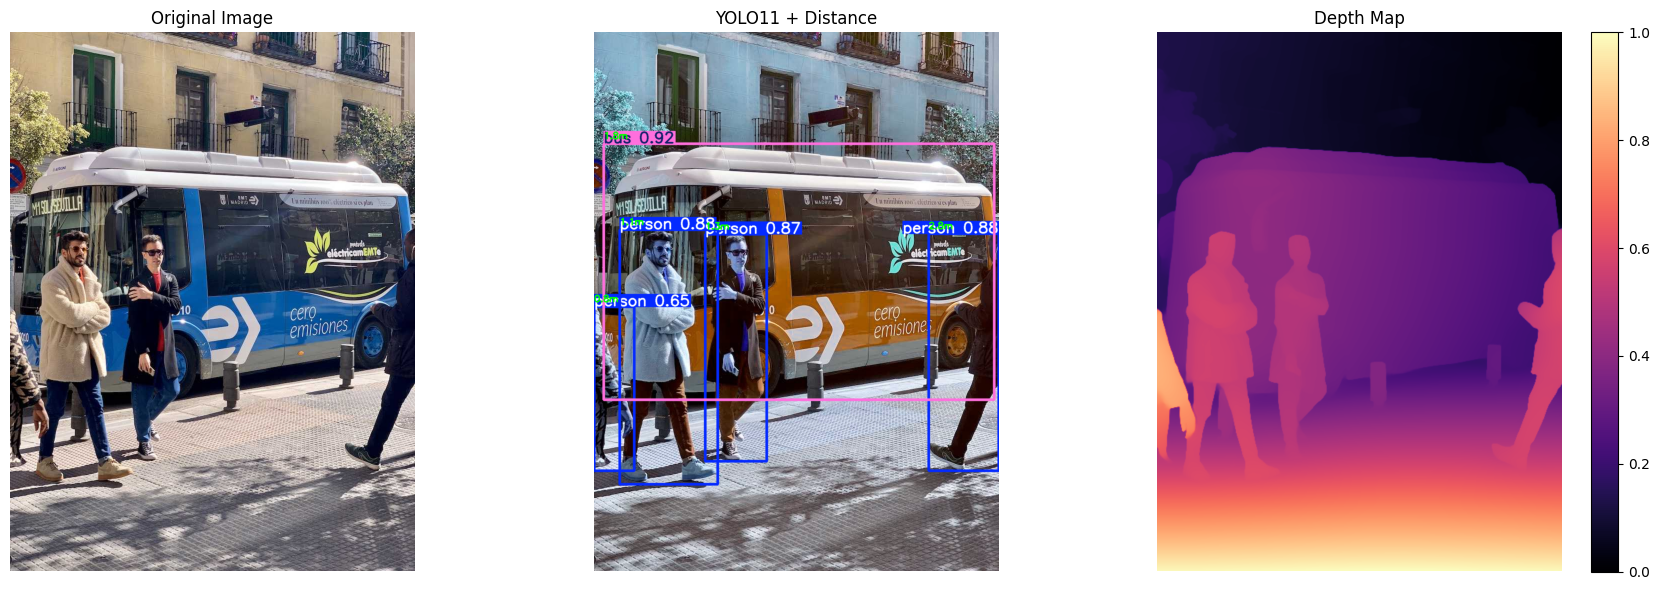

In [11]:
# Test 1: Street / Outdoor
analyze_with_depth("https://ultralytics.com/images/bus.jpg")

# Test 2: Indoor (change link)
# analyze_with_depth("https://source.unsplash.com/random/800x600/?indoor")

# Test 3: People
# analyze_with_depth("https://source.unsplash.com/random/800x600/?people")